In [21]:
import pandas as pd
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
loan_df = pd.read_csv('loan_data.csv')
loan_df.sort_values('loan_length', ascending=False).head()
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2498 entries, 0 to 2497
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   interest_rate               2498 non-null   float64
 1   fico_range                  2498 non-null   object 
 2   amount_requested            2498 non-null   float64
 3   amount_funded_by_investors  2498 non-null   float64
 4   loan_length                 2498 non-null   float64
dtypes: float64(4), object(1)
memory usage: 97.7+ KB


In [22]:
loan_df['fico_base'] = loan_df['fico_range'].str.split('-').str[0]
loan_df['fico_base'] = loan_df['fico_base'].astype(float)
loan_df.head()

,interest_rate,fico_range,amount_requested,amount_funded_by_investors,loan_length,fico_base
0,8.90,735-739,20000.0,20000.0,36.0,735.0
1,12.12,715-719,19200.0,19200.0,36.0,715.0
2,21.98,690-694,35000.0,35000.0,60.0,690.0
3,9.99,695-699,10000.0,9975.0,36.0,695.0
4,11.71,695-699,12000.0,12000.0,36.0,695.0


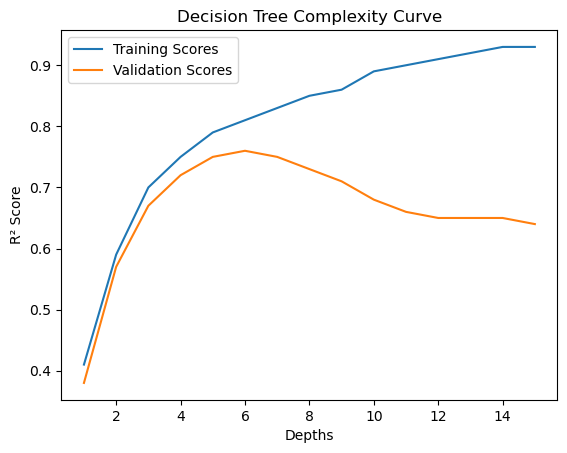

In [31]:
import matplotlib.pyplot as plt

X = loan_df[['amount_requested', 'fico_base', 'loan_length']]
y = loan_df['interest_rate']
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

X_train, X_vals, y_train, y_vals = train_test_split(
    X, y, test_size=0.25, random_state=42
    )

depths = range(1, 16)
training_r2 = []
val_r2 = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    val_score = model.score(X_vals, y_vals)

    training_r2.append(round(train_score, 2))
    val_r2.append(round(val_score, 2))

plt.plot(depths, training_r2, label="Training Scores")
plt.plot(depths, val_r2, label="Validation Scores")

plt.xlabel("Depths")
plt.ylabel("R² Score")
plt.title("Decision Tree Complexity Curve")
plt.legend()
plt.show()

best_depth = 6



In [33]:
model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
model.fit(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f'Test R^2: {test_score}')

Test R^2: 0.7499769512571768


In [38]:
def predict_interest_rate(fico_base, amount_requested, loan_length):
    X = loan_df[['amount_requested', 'fico_base', 'loan_length']]
    y = loan_df['interest_rate']
    model = DecisionTreeRegressor(max_depth=6, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
        )
    model.fit(X_train, y_train)
    print(f'Estimated Interest Rate: {model.predict([[fico_base, amount_requested, loan_length]])}')

predict_interest_rate(650, 20000, 30)

Estimated Interest Rate: [7.08951613]


c:\Users\Lemons\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
